# Diving: Matched Pairs Permutation Testing

In 2017 female divers competed in an international diving competition. Their semi-final and final scores are the sum of a total of 5 dives.

Are the difference in mean diving scores in the semi-final and finals due to random chance?

$H_0: \mu_s=\mu_f$<br>
$H_A: \mu_s \ne \mu_f$

In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.style.use("ggplot")

In [57]:
# Read data
diver_scores = pd.read_csv("../Data/Diving2017.csv")

print(diver_scores)

                      Name      Country  Semifinal   Final
0         CHEONG Jun Hoong     Malaysia     325.50  397.50
1                 SI Yajie        China     382.80  396.00
2                 REN Qian        China     367.50  391.95
3               KIM Mi Rae  North Korea     346.00  385.55
4               WU Melissa    Australia     318.70  370.20
5            KIM Kuk Hyang  North Korea     360.85  360.00
6          ITAHASHI Minami        Japan     313.70  357.85
7         BENFEITO Meaghan       Canada     355.15  331.40
8           PAMG Pandelela     Malaysia     322.75  322.40
9          CHAMANDY Olivia       Canada     320.55  307.15
10        PARRATTO Jessica          USA     322.75  302.35
11  MURILLO URREA Carolina     Colombia     325.75  283.35


In [58]:
# Compute the observed test statistic
mu_s = diver_scores["Semifinal"].mean()
mu_f = diver_scores["Final"].mean()

print(f"Mean Semifinal Score: {mu_s:4f}")
print(f"Mean Final Score: {mu_f:4f}")

diff_scores = diver_scores["Final"] - diver_scores["Semifinal"]
t_obs = diff_scores.mean()

print(f"Observed Test Statistic: {t_obs}")

Mean Semifinal Score: 338.500000
Mean Final Score: 350.475000
Observed Test Statistic: 11.975


In [59]:
# Matched Pairs Permutation Test
T = 10_000

perm_t = []
for i in range(T):
    # Random transpose
    sign = np.random.choice((-1, 1), size=len(diver_scores), replace=True)
    t_diff = diff_scores * sign
    perm_t.append(t_diff.mean())

# Compute the 2-sided p-value
perm_t = np.array(perm_t)
p_val = 2 * ((sum(perm_t >= t_obs) + 1) / (T + 1))

print(f"P-Value: {p_val}")

P-Value: 0.26017398260173985


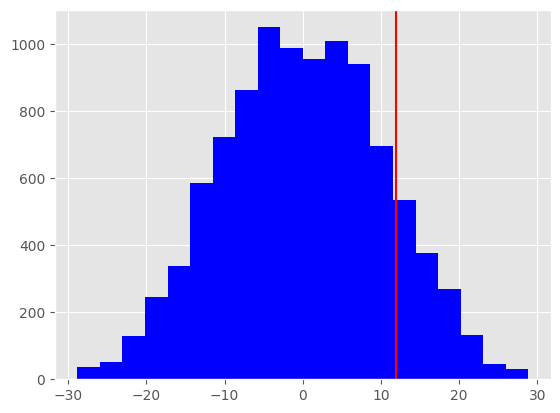

In [60]:
# Permutation Distribution
plt.hist(perm_t, bins=20, color="blue")
plt.axvline(t_obs, color="red")
plt.show()

The p-value suggests we should fail to reject $H_0$ and conclude that the mean diving scores between the Semifinal and Final rounds are equivalent, and that chance alone may account for the difference in diving scores.